In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("housing.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [6]:
df.head()



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [7]:
df.shape

(20640, 10)

In [8]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [9]:
corr = df.corr(numeric_only=True)

corr["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

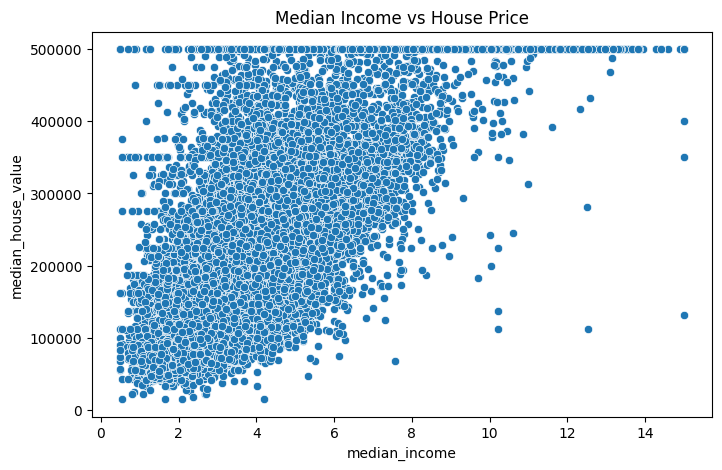

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="median_income",
    y="median_house_value"
)

plt.title("Median Income vs House Price")
plt.show()

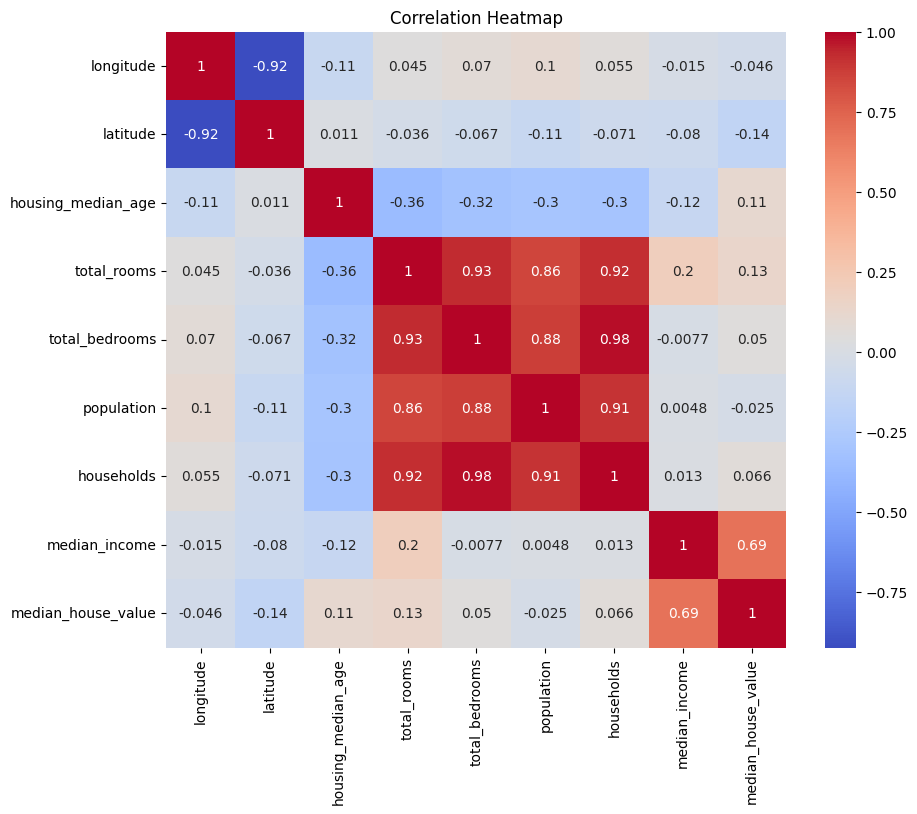

In [11]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [15]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [17]:
df.groupby("ocean_proximity")["median_house_value"].mean()

ocean_proximity
<1H OCEAN     240084.285464
INLAND        124805.392001
ISLAND        380440.000000
NEAR BAY      259212.311790
NEAR OCEAN    249433.977427
Name: median_house_value, dtype: float64

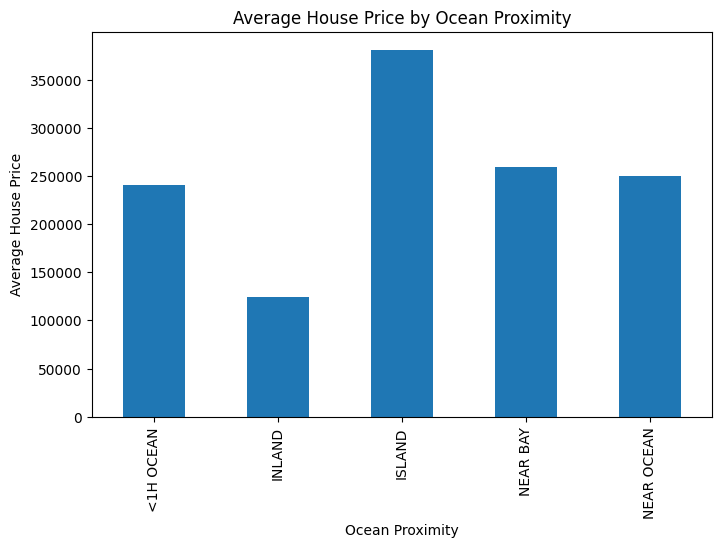

In [18]:
import matplotlib.pyplot as plt

avg_prices = df.groupby("ocean_proximity")["median_house_value"].mean()

plt.figure(figsize=(8,5))
avg_prices.plot(kind="bar")

plt.title("Average House Price by Ocean Proximity")
plt.xlabel("Ocean Proximity")
plt.ylabel("Average House Price")
plt.show()

In [19]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(
    df["total_bedrooms"].median()
)

In [20]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [22]:
df["rooms_per_household"] = (
    df["total_rooms"] / df["households"]
)

df[["total_rooms","households","rooms_per_household"]].head()

,total_rooms,households,rooms_per_household
0,880.0,126.0,6.984127
1,7099.0,1138.0,6.238137
2,1467.0,177.0,8.288136
3,1274.0,219.0,5.817352
4,1627.0,259.0,6.281853


In [23]:
corr = df.corr(numeric_only=True)

corr["median_house_value"].sort_values(ascending=False)

median_house_value     1.000000
median_income          0.688075
rooms_per_household    0.151948
total_rooms            0.134153
housing_median_age     0.105623
households             0.065843
total_bedrooms         0.049457
population            -0.024650
longitude             -0.045967
latitude              -0.144160
Name: median_house_value, dtype: float64

In [27]:
df["bedrooms_per_room"] = (
    df["total_bedrooms"] / df["total_rooms"]
)

In [28]:
df["people_per_household"] = (
    df["population"] / df["households"]
)

In [29]:
corr = df.corr(numeric_only=True)

corr["median_house_value"].sort_values(ascending=False)

median_house_value      1.000000
median_income           0.688075
rooms_per_household     0.151948
total_rooms             0.134153
housing_median_age      0.105623
households              0.065843
total_bedrooms          0.049457
people_per_household   -0.023737
population             -0.024650
longitude              -0.045967
latitude               -0.144160
bedrooms_per_room      -0.233303
Name: median_house_value, dtype: float64

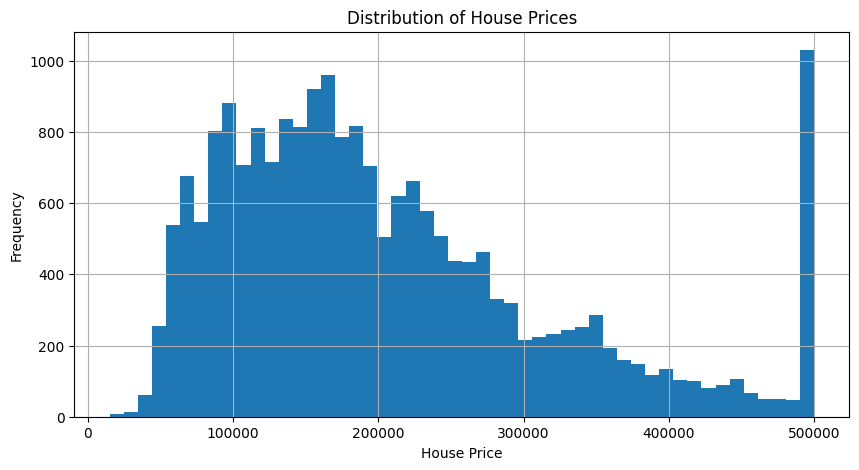

In [30]:
df["median_house_value"].hist(bins=50, figsize=(10,5))
plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")
plt.show()

In [31]:
housing_encoded = pd.get_dummies(
    df,
    columns=["ocean_proximity"],
    drop_first=True
)

In [32]:
housing_encoded.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,people_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,0.146591,2.555556,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,0.155797,2.109842,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,0.129516,2.802260,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,0.184458,2.547945,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,0.172096,2.181467,False,False,True,False


In [33]:
X = housing_encoded.drop("median_house_value", axis=1)

y = housing_encoded["median_house_value"]

In [34]:
print(X.shape)
print(y.shape)

(20640, 15)
(20640,)


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16512, 15)
(4128, 15)
(16512,)
(4128,)


In [37]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
predictions = model.predict(X_test)
print(predictions)

[ 61463.74466641 121631.21809998 267594.25389059 ... 447837.04647878
 117275.92146079 185597.46125195]


In [39]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

comparison.head(10)

,Actual,Predicted
20046,47700.0,61463.744666
3024,45800.0,121631.218100
15663,500001.0,267594.253891
20484,218600.0,264252.963820
9814,278000.0,258213.789828
13311,158700.0,151805.134515
7113,198200.0,308380.085708
7668,157500.0,243588.672418
18246,340000.0,257766.450671
5723,446600.0,410596.381660


In [40]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = mse ** 0.5

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 50888.660015720314
RMSE: 72668.53837868226
R² Score: 0.5970176824350761


In [41]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
rf_predictions = rf_model.predict(X_test)

In [43]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = mean_squared_error(y_test, rf_predictions) ** 0.5
rf_r2 = r2_score(y_test, rf_predictions)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

MAE: 32328.370368217053
RMSE: 50356.59653064188
R²: 0.8064889010792716


In [44]:
print(rf_predictions[:10])

[ 48573.   112198.   458446.44 270608.   233581.   190347.   265778.09
 166174.   249613.03 482237.8 ]


In [45]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": rf_predictions
})

comparison.head(10)

,Actual,Predicted
20046,47700.0,48573.00
3024,45800.0,112198.00
15663,500001.0,458446.44
20484,218600.0,270608.00
9814,278000.0,233581.00
13311,158700.0,190347.00
7113,198200.0,265778.09
7668,157500.0,166174.00
18246,340000.0,249613.03
5723,446600.0,482237.80


In [46]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
7,median_income,0.481661
11,ocean_proximity_INLAND,0.137520
10,people_per_household,0.121586
0,longitude,0.057939
1,latitude,0.056532
2,housing_median_age,0.044267
8,rooms_per_household,0.025967
9,bedrooms_per_room,0.024248
3,total_rooms,0.012499
4,total_bedrooms,0.012137


In [47]:
print(X.shape)
print(rf_r2)

(20640, 15)
0.8064889010792716


In [48]:
print("Random Forest R²:", rf_r2)

Random Forest R²: 0.8064889010792716


In [49]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
7,median_income,0.481661
11,ocean_proximity_INLAND,0.137520
10,people_per_household,0.121586
0,longitude,0.057939
1,latitude,0.056532
2,housing_median_age,0.044267
8,rooms_per_household,0.025967
9,bedrooms_per_room,0.024248
3,total_rooms,0.012499
4,total_bedrooms,0.012137


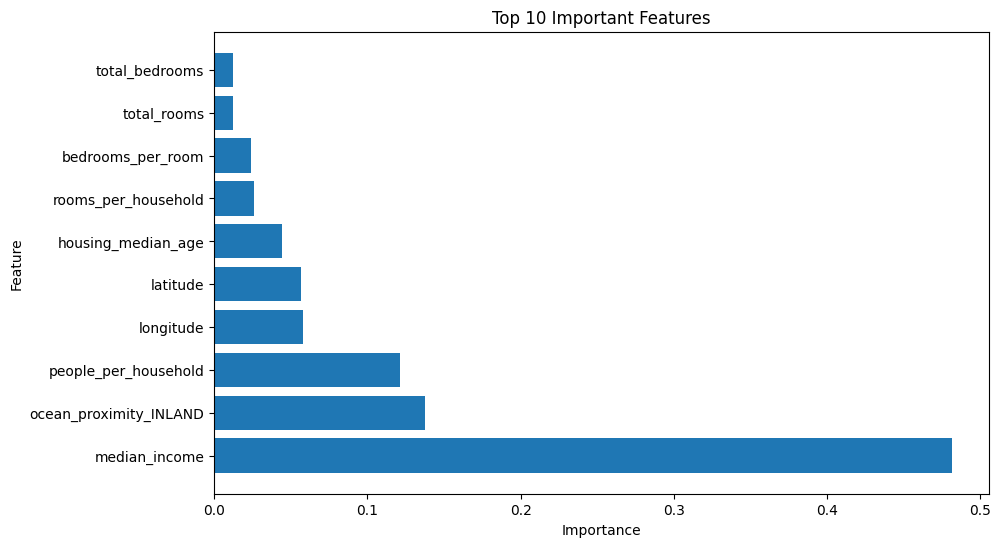

In [50]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [51]:
import joblib

joblib.dump(rf_model, "house_price_model.pkl")

['house_price_model.pkl']

In [52]:
import os

print(os.path.exists("house_price_model.pkl"))

True


In [53]:
print(X.columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'people_per_household', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
